# Using LLMs to Improve RL Policies in Personalized Health Adaptive Interventions

## What this notebook implements:
1. **StepCountJITAI for LLM** — simulation environment with `can_walk` / `cannot_walk` hidden state
2. **Standard Thompson Sampling (TS)** — baseline
3. **LLM+TS** — LLM as action filter
4. **Research Question:**
   - Sliding Window Thompson Sampling (SW-TS)
   - Discounted Thompson Sampling (D-TS)
   - Non-Stationary Linear Bandits with Kalman Filtering (KF-TS)
5. **Probabilistic LLM filter** — soft probability instead of hard binary decision

- llama-3.1-8b-instant (a lightw
- NumPy, Matplotlib, SciPy


## 0. Install Dependencies

In [ ]:
# Install required packages
!pip install -q transformers accelerate huggingface_hub
!pip install -q matplotlib numpy scipy tqdm
print('All packages installed!')

All packages installed!


## 1. Imports & Configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
from tqdm import tqdm
import warnings
import random
import json
import re
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CFG = dict(
    MAX_DAYS        = 50,          # maximum study length
    N_TRIALS        = 5,           # repetitions per setting
    N_ACTIONS       = 4,           # 0=no msg, 1=generic, 2=ctx0, 3=ctx1

    SIGMA           = 0.4,         # context uncertainty
    DELTA_H         = 0.1,         # habituation decay
    EPS_H           = 0.05,        # habituation increment
    DELTA_D         = 0.1,         # disengagement decay
    EPS_D           = 0.4,         # disengagement increment
    MS              = 0.1,         # baseline step count
    RHO1            = 50,          # reward for generic message
    RHO2            = 200,         # reward for context-tailored message
    D_THRESHOLD     = 0.99,        # disengagement threshold

    # eta_d — penalty for messaging when cannot walk
    ETA_D           = 0.4,         # paper uses 0.4 in main figures

    # Thompson Sampling prior
    MU0             = 0.0,
    SIGMA0          = 100.0,       # prior std
    SIGMA_Y         = 25.0,        # reward noise std

    # Sliding Window TS
    SW_WINDOW       = 10,          # window size

    # Discounted TS
    DISCOUNT_GAMMA  = 0.95,        # discount factor

    # Kalman Filter TS
    KF_Q            = 1.0,         # process noise
    KF_R            = 25.0**2,     # observation noise

    # Scenarios (pw11, pw00)
    SCENARIOS       = [
        (0.7, 0.1), (0.7, 0.5),
        (0.95, 0.1), (0.95, 0.5)
    ],

    # LLM
    LLM_TEMPERATURE = 0.2,
    USE_HF_API      = True,
    HF_MODEL        = 'meta-llama/Meta-Llama-3-8B-Instruct',
    FALLBACK_MODEL  = 'google/gemma-2-2b-it',
)

print('Configuration loaded.')
print(f"Scenarios: {CFG['SCENARIOS']}")
print(f"Trials per scenario: {CFG['N_TRIALS']}")

Configuration loaded.
Scenarios: [(0.7, 0.1), (0.7, 0.5), (0.95, 0.1), (0.95, 0.5)]
Trials per scenario: 5


## 2. StepCountJITAI Simulation Environment

Implements the full environment from Appendix A.1 + B (new `W` state variable).

In [ ]:
import pandas as pd

df = pd.read_csv("expanded_project_dataset.csv")

CANNOT_WALK_PREFS = df[df["can_walk"] == 0]["preference_text"].tolist()
CAN_WALK_PREFS = df[df["can_walk"] == 1]["preference_text"].tolist()

val_cannot = [(p, 0) for p in CANNOT_WALK_PREFS]
val_can = [(p, 1) for p in CAN_WALK_PREFS]
val_data = val_cannot + val_can

import random

random.shuffle(CANNOT_WALK_PREFS)
random.shuffle(CAN_WALK_PREFS)

class StepCountJITAI:

    def __init__(self, pw11: float, pw00: float, cfg: dict = CFG):
        """
        pw11 : P(w_t+1=1 | w_t=1)  — probability of staying 'can walk'
        pw00 : P(w_t+1=0 | w_t=0)  — probability of staying 'cannot walk'
        """
        self.cfg   = cfg
        self.pw11  = pw11
        self.pw00  = pw00
        self.pw01  = 1.0 - pw00
        self.pw10  = 1.0 - pw11
        self.reset()

    def reset(self):
        cfg = self.cfg
        self.t           = 0
        self.h           = 0.0    # habituation level
        self.d           = 0.0    # disengagement risk
        self.w           = 1      # hidden walk state: 1=can walk, 0=cannot
        self.prev_w      = 1
        self.done        = False
        self.pref_text   = None   # current user preference text
        self.pref_true_w = None   # true w corresponding to preference
        self.c = int(np.random.binomial(1, 0.5))
        return self._get_obs_state()

    def _get_obs_state(self):
        return dict(h=self.h, d=self.d, c=self.c)

    def _update_w(self):
        """Markov transition for hidden walk state."""
        self.prev_w = self.w
        if self.w == 0:
            self.w = int(np.random.binomial(1, self.pw01))
        else:
            self.w = int(np.random.binomial(1, self.pw11))

    def _generate_preference(self):
        prev, curr = self.prev_w, self.w
        # Transition 1→0: injury event
        if prev == 1 and curr == 0:
            text = random.choice(CANNOT_WALK_PREFS)
            return text, 0
        # Transition 0→1: recovery
        elif prev == 0 and curr == 1:
            text = random.choice(CAN_WALK_PREFS)
            return text, 1
        # Staying in can_walk: emit with prob 0.3
        elif curr == 1 and np.random.binomial(1, 0.3):
            text = random.choice(CAN_WALK_PREFS)
            return text, 1
        return None, None

    def step(self, action: int):
        """
        action: 0–3  (the FINAL action after LLM filtering if applicable)
        Returns: (obs_state, reward, done, info)
        """
        cfg = self.cfg
        a, w, c = action, self.w, self.c

        c_new = int(np.random.binomial(1, 0.5))
        x_new = np.random.normal(c_new, cfg['SIGMA'])
        p_new = norm.cdf(x_new)           # P(C=1|x)
        l_new = int(p_new > 0.5)          # inferred context

        # ── Eq (12): habituation ──────────────────────────────────────────────
        if a == 0:
            h_new = (1 - cfg['DELTA_H']) * self.h
        else:
            h_new = min(1.0, self.h + cfg['EPS_H'])

        # ── Eq (13): disengagement — with new constraints ─────────────────────
        if a == 0:
            d_new = self.d
        elif a in (1, c + 2):  # correct action
            if w == 1:  # can walk → good, reduce risk
                d_new = (1 - cfg['DELTA_D']) * self.d
            else:       # cannot walk → single penalty (correct context but wrong timing)
                d_new = min(1.0, self.d + cfg['ETA_D'])
        else:           # incorrect context action
            if w == 1:
                d_new = min(1.0, self.d + cfg['EPS_D'])
            else:       # double penalty
                d_new = min(1.0, self.d + cfg['EPS_D'] + (1 - w) * cfg['ETA_D'])

        # ── Eq (14): step count reward ────────────────────────────────────────
        if a == 1 and w == 1:
            r = cfg['MS'] + (1 - h_new) * cfg['RHO1']
        elif a == c + 2 and w == 1:
            r = cfg['MS'] + (1 - h_new) * cfg['RHO2']
        else:
            r = cfg['MS'] * w   # 0 if cannot walk, baseline if a=0

        # ── Update state ──────────────────────────────────────────────────────
        self.h = h_new
        self.d = d_new
        self.c = c_new
        self.t += 1

        # ── Walk state transition & preference ───────────────────────────────
        self._update_w()
        self.pref_text, self.pref_true_w = self._generate_preference()

        # ── Check done ───────────────────────────────────────────────────────
        self.done = (d_new >= cfg['D_THRESHOLD']) or (self.t >= cfg['MAX_DAYS'])

        obs = self._get_obs_state()
        info = dict(w=w, true_c=c, inferred_c=l_new, h=h_new, d=d_new,
                    pref=self.pref_text, pref_true_w=self.pref_true_w)
        return obs, r, self.done, info


print('StepCountJITAI environment defined.')

StepCountJITAI environment defined.


## 3. Thompson Sampling Variants

Implements:
- Standard TS (paper baseline)
- Sliding Window TS (SW-TS)
- Discounted TS (D-TS)
- Kalman Filter TS (KF-TS)

In [ ]:
def obs_to_vec(obs):
    """Convert observation dict to feature vector for linear TS."""
    return np.array([1.0, obs['h'], obs['d'], obs['c']], dtype=np.float64)


# ─────────────────────────────────────────────────────────────────────────────
# 1. Standard Thompson Sampling
# ─────────────────────────────────────────────────────────────────────────────
class ThompsonSampling:

    def __init__(self, n_actions=4, dim=4, cfg=CFG):
        self.n_actions = n_actions
        self.dim       = dim
        self.sigma_y   = cfg['SIGMA_Y']
        self.reset(cfg)

    def reset(self, cfg=CFG):
        sigma0 = cfg['SIGMA0']
        self.mu    = [np.zeros(self.dim) for _ in range(self.n_actions)]
        self.Sigma = [sigma0**2 * np.eye(self.dim) for _ in range(self.n_actions)]

    def select_action(self, obs):
        v = obs_to_vec(obs)
        scores = []
        for a in range(self.n_actions):
            theta_hat = np.random.multivariate_normal(self.mu[a], self.Sigma[a])
            scores.append(theta_hat @ v)
        return int(np.argmax(scores))

    def update(self, obs, action, reward):
        v  = obs_to_vec(obs)
        sy2 = self.sigma_y ** 2
        S   = self.Sigma[action]
        mu  = self.mu[action]
        S_new  = sy2 * np.linalg.inv(np.outer(v, v) + sy2 * np.linalg.inv(S))
        mu_new = S_new @ (reward * v / sy2 + np.linalg.inv(S) @ mu)
        self.Sigma[action] = S_new
        self.mu[action]    = mu_new


# ─────────────────────────────────────────────────────────────────────────────
# 2. Sliding Window Thompson Sampling
# ─────────────────────────────────────────────────────────────────────────────
class SlidingWindowTS:

    def __init__(self, n_actions=4, dim=4, cfg=CFG):
        self.n_actions = n_actions
        self.dim       = dim
        self.sigma_y   = cfg['SIGMA_Y']
        self.window    = cfg['SW_WINDOW']
        self.sigma0    = cfg['SIGMA0']
        self._init_buffers()

    def _init_buffers(self):
        # Circular buffer per action
        self.buf_v = [[] for _ in range(self.n_actions)]
        self.buf_r = [[] for _ in range(self.n_actions)]

    def reset(self, cfg=CFG):
        self._init_buffers()

    def _compute_posterior(self, action):
        sy2   = self.sigma_y ** 2
        S_inv = np.eye(self.dim) / (self.sigma0 ** 2)
        b     = np.zeros(self.dim)
        for v, r in zip(self.buf_v[action], self.buf_r[action]):
            S_inv += np.outer(v, v) / sy2
            b     += r * v / sy2
        S  = np.linalg.inv(S_inv)
        mu = S @ b
        return mu, S

    def select_action(self, obs):
        v = obs_to_vec(obs)
        scores = []
        for a in range(self.n_actions):
            mu, S = self._compute_posterior(a)
            theta_hat = np.random.multivariate_normal(mu, S)
            scores.append(theta_hat @ v)
        return int(np.argmax(scores))

    def update(self, obs, action, reward):
        v = obs_to_vec(obs)
        self.buf_v[action].append(v)
        self.buf_r[action].append(reward)
        # Keep only last W observations
        if len(self.buf_v[action]) > self.window:
            self.buf_v[action].pop(0)
            self.buf_r[action].pop(0)


# ─────────────────────────────────────────────────────────────────────────────
# 3. Discounted Thompson Sampling
# ─────────────────────────────────────────────────────────────────────────────
class DiscountedTS:

    def __init__(self, n_actions=4, dim=4, cfg=CFG):
        self.n_actions = n_actions
        self.dim       = dim
        self.sigma_y   = cfg['SIGMA_Y']
        self.gamma     = cfg['DISCOUNT_GAMMA']
        self.sigma0    = cfg['SIGMA0']
        self.reset(cfg)

    def reset(self, cfg=CFG):
        s0 = self.sigma0 ** 2
        self.A  = [s0 * np.eye(self.dim) for _ in range(self.n_actions)]
        self.b  = [np.zeros(self.dim)    for _ in range(self.n_actions)]
        self.cnt = np.zeros(self.n_actions, dtype=int)

    def select_action(self, obs):
        v = obs_to_vec(obs)
        sy2 = self.sigma_y ** 2
        scores = []
        for a in range(self.n_actions):
            S  = np.linalg.inv(self.A[a] / sy2)
            mu = S @ (self.b[a] / sy2)
            theta_hat = np.random.multivariate_normal(mu, S)
            scores.append(theta_hat @ v)
        return int(np.argmax(scores))

    def update(self, obs, action, reward):
        v = obs_to_vec(obs)
        g = self.gamma
        # Discount existing stats
        self.A[action] = g * self.A[action] + np.outer(v, v)
        self.b[action] = g * self.b[action] + reward * v
        self.cnt[action] += 1


# ─────────────────────────────────────────────────────────────────────────────
# 4. Kalman Filter Thompson Sampling (Non-Stationary Linear Bandits)
# ─────────────────────────────────────────────────────────────────────────────
class KalmanFilterTS:

    def __init__(self, n_actions=4, dim=4, cfg=CFG):
        self.n_actions = n_actions
        self.dim       = dim
        self.Q  = cfg['KF_Q'] * np.eye(dim)
        self.R  = cfg['KF_R']
        self.sigma0 = cfg['SIGMA0']
        self.reset(cfg)

    def reset(self, cfg=CFG):
        s0 = self.sigma0 ** 2
        self.mu    = [np.zeros(self.dim)        for _ in range(self.n_actions)]
        self.Sigma = [s0 * np.eye(self.dim)     for _ in range(self.n_actions)]

    def _predict(self, action):
        """KF prediction step: add process noise."""
        self.Sigma[action] = self.Sigma[action] + self.Q

    def select_action(self, obs):
        v = obs_to_vec(obs)
        scores = []
        for a in range(self.n_actions):
            theta_hat = np.random.multivariate_normal(self.mu[a], self.Sigma[a])
            scores.append(theta_hat @ v)
        return int(np.argmax(scores))

    def update(self, obs, action, reward):
        v = obs_to_vec(obs)
        # Prediction
        self._predict(action)
        # Innovation
        y_pred   = self.mu[action] @ v
        S_innov  = v @ self.Sigma[action] @ v + self.R
        K        = (self.Sigma[action] @ v) / S_innov
        self.mu[action]    = self.mu[action] + K * (reward - y_pred)
        self.Sigma[action] = self.Sigma[action] - np.outer(K, v) @ self.Sigma[action]


print('Comparing the following Variants:')
print('  1. ThompsonSampling     (standard TS)')
print('  2. SlidingWindowTS      (SW-TS)')
print('  3. DiscountedTS         (D-TS)')
print('  4. KalmanFilterTS       (KF-TS)')

Comparing the following Variants:
  1. ThompsonSampling     (standard TS)
  2. SlidingWindowTS      (SW-TS)
  3. DiscountedTS         (D-TS)
  4. KalmanFilterTS       (KF-TS)


In [ ]:
GROQ_API_KEY   = None
GEMINI_API_KEY = None

try:
    from google.colab import userdata
    try:
        GROQ_API_KEY   = userdata.get('GROQ_API_KEY')
        print('Groq key loaded.')
    except: pass
    try:
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
        print('Gemini key loaded.')
    except: pass
except: pass

import requests, time, re, json

LLM_BACKEND = 'fallback'

if GROQ_API_KEY:
    try:
        r = requests.post(
            'https://api.groq.com/openai/v1/chat/completions',
            headers={'Authorization': f'Bearer {GROQ_API_KEY}',
                     'Content-Type': 'application/json'},
            json={'model': 'llama-3.1-8b-instant',
                  'messages': [{'role': 'user', 'content': 'Reply OK'}],
                  'max_tokens': 5},
            timeout=15
        )
        if r.status_code == 200:
            LLM_BACKEND = 'groq'
            print(f'✓ Groq active → llama-3.1-8b-instant')
        else:
            print(f'Groq failed ({r.status_code}): {r.text[:300]}')
            print('Trying model llama3-70b-8192 as fallback...')
            r2 = requests.post(
                'https://api.groq.com/openai/v1/chat/completions',
                headers={'Authorization': f'Bearer {GROQ_API_KEY}',
                         'Content-Type': 'application/json'},
                json={'model': 'llama3-70b-8192',
                      'messages': [{'role': 'user', 'content': 'Reply OK'}],
                      'max_tokens': 5},
                timeout=15
            )
            if r2.status_code == 200:
                GROQ_MODEL = 'llama3-70b-8192'
                LLM_BACKEND = 'groq'
                print(f'✓ Groq active → llama3-70b-8192')
            else:
                print(f'Second Groq model also failed: {r2.text[:200]}')
    except Exception as e:
        print(f'Groq error: {e}')
else:
    print('No Groq key.')

if LLM_BACKEND == 'groq':
    try:
        GROQ_MODEL
    except NameError:
        GROQ_MODEL = 'llama-3.1-8b-instant'

if LLM_BACKEND == 'fallback' and GEMINI_API_KEY:
    try:
        r = requests.post(
            'https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent',
            params={'key': GEMINI_API_KEY},
            json={'contents': [{'parts': [{'text': 'Reply OK'}]}],
                  'generationConfig': {'maxOutputTokens': 10}},
            timeout=15
        )
        if r.status_code == 200:
            LLM_BACKEND = 'gemini'
            print(f'✓ Gemini active → gemini-1.5-flash-latest')
        else:
            print(f'Gemini failed ({r.status_code}): {r.text[:300]}')
    except Exception as e:
        print(f'Gemini error: {e}')

if LLM_BACKEND == 'fallback':
    print('\n⚠  Using rule-based fallback (~87% accuracy).')

print(f'\nActive backend: {LLM_BACKEND.upper()}')

Groq key loaded.
Gemini key loaded.
✓ Groq active → llama-3.1-8b-instant

Active backend: GROQ


In [ ]:
SYSTEM_PROMPT = (
    "You are a decision-support assistant for a mobile health app. "
    "Decide whether to send or NOT send a walking encouragement message. "
    "Reply ONLY with valid JSON — no markdown, no explanation outside it:\n"
    '{"reasoning": "<brief>", "decision": "send" or "not send", '
    '"confidence": <float 0.0-1.0 that user CAN walk>}'
)

def build_llm_prompt(user_pref, candidate_action):
    action_desc = {0:'no message', 1:'a generic walking encouragement message',
                   2:"a message tailored to context 0",
                   3:"a message tailored to context 1"}[candidate_action]
    return f"""A mobile health app wants to send {action_desc} to encourage walking.

Behavioral rules:
- If user is sick, injured, or cannot walk → do NOT send. It increases disengagement.
- If user is fine → sending a well-timed message decreases disengagement risk.

User said this morning: "{user_pref}"

Answer briefly then give ONLY this JSON (no extra text):
{{"reasoning": "<brief>", "decision": "send" or "not send", "confidence": <0.0-1.0>}}"""


# ── Rule-based fallback ───────────────────────────────────────────────────────
CANNOT_WALK_KW = [
    'tired','injur','headache','sore','twisted','dizzy','breath','cold',
    'weak','muscle','knee','blister','nauseous','cramp',"don't have time",
    'waiting','hot outside','cold outside','fever','swollen','hurt',
    'pain','exhausted','sprained'
]

def rule_based_llm(user_pref):
    text = user_pref.lower()
    if ('anxiety' in text or 'anxious' in text) and np.random.random() < 0.30:
        return {'decision':'send','confidence':0.6,
                'reasoning':'Emotional state; message may help.'}
    for kw in CANNOT_WALK_KW:
        if kw in text:
            return {'decision':'not send','confidence':0.05,
                    'reasoning':f'Physical limitation: {kw}.'}
    return {'decision':'send','confidence':0.90,
            'reasoning':'No limitation detected.'}


def _parse_response(text):
    text = re.sub(r'```(?:json)?', '', text).strip()
    match = re.search(r'\{[^{}]*"decision"[^{}]*\}', text, re.DOTALL)
    if match:
        try:
            p = json.loads(match.group())
            return {'decision':   p.get('decision','send').strip().lower(),
                    'confidence': float(p.get('confidence', 0.5)),
                    'reasoning':  str(p.get('reasoning', ''))}
        except: pass
    tl = text.lower()
    if 'not send' in tl or "don't send" in tl or 'should not' in tl:
        return {'decision':'not send','confidence':0.1,'reasoning':'Parsed from text.'}
    return {'decision':'send','confidence':0.8,'reasoning':'Parsed from text.'}


def _call_groq(user_pref, candidate_action):
    r = requests.post(
        'https://api.groq.com/openai/v1/chat/completions',
        headers={'Authorization': f'Bearer {GROQ_API_KEY}',
                 'Content-Type': 'application/json'},
        json={'model': GROQ_MODEL,
              'messages': [{'role':'system','content':SYSTEM_PROMPT},
                           {'role':'user','content':build_llm_prompt(user_pref, candidate_action)}],
              'max_tokens': 180,
              'temperature': CFG['LLM_TEMPERATURE']},
        timeout=25
    )
    r.raise_for_status()
    return _parse_response(r.json()['choices'][0]['message']['content'])


def _call_gemini(user_pref, candidate_action):
    full = f"{SYSTEM_PROMPT}\n\n{build_llm_prompt(user_pref, candidate_action)}"
    r = requests.post(
        'https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent',
        params={'key': GEMINI_API_KEY},
        json={'contents': [{'parts': [{'text': full}]}],
              'generationConfig': {'temperature': CFG['LLM_TEMPERATURE'],
                                   'maxOutputTokens': 180}},
        timeout=25
    )
    r.raise_for_status()
    return _parse_response(r.json()['candidates'][0]['content']['parts'][0]['text'])


_llm_cache = {}

def llm_infer(user_pref, candidate_action, max_retries=2):
    key = f'{user_pref}|{candidate_action}'
    if key in _llm_cache:
        return _llm_cache[key]

    result = None
    for attempt in range(max_retries):
        try:
            if LLM_BACKEND == 'groq':
                result = _call_groq(user_pref, candidate_action)
            elif LLM_BACKEND == 'gemini':
                result = _call_gemini(user_pref, candidate_action)
            else:
                result = rule_based_llm(user_pref)
            break
        except requests.HTTPError as e:
            code = e.response.status_code if e.response else 0
            if code == 429:
                wait = 60 if LLM_BACKEND == 'groq' else 30
                print(f'Rate limited, waiting {wait}s...')
                time.sleep(wait)
            else:
                print(f'HTTP {code} on attempt {attempt+1}, details: {e.response.text[:200] if e.response else ""}')
                result = rule_based_llm(user_pref)
                break
        except Exception as e:
            print(f'Attempt {attempt+1} error: {e}')
            time.sleep(2)

    if result is None:
        result = rule_based_llm(user_pref)

    _llm_cache[key] = result
    return result


print('Testing inference...\n')
for pref in ['I twisted my ankle', 'I feel great today', 'I am dealing with anxiety']:
    res = llm_infer(pref, 1)
    print(f'  "{pref}"')
    print(f'    decision={res["decision"]}  confidence={res["confidence"]:.2f}')
    print(f'    {res["reasoning"][:80]}\n')

Testing inference...

  "I twisted my ankle"
    decision=not send  confidence=1.00
    User is injured, cannot walk

  "I feel great today"
    decision=send  confidence=0.90
    User reported feeling great, no health issues mentioned

  "I am dealing with anxiety"
    decision=send  confidence=0.80
    Anxiety does not directly affect walking ability, so sending a walking encourage



## 5. LLM+TS Method — Binary & Probabilistic Variants

**Binary (paper's approach):** LLM decides hard 'send' / 'not send'.  
**Probabilistic (extension):** LLM returns P(can_walk). Action is suppressed with probability proportional to (1 - P(can_walk)).

In [ ]:
def llm_filter_binary(candidate_action: int, pref_text: str) -> int:
    """
    Binary filter (paper method).
    If LLM says 'not send' → action becomes 0.
    Returns final action.
    """
    if candidate_action == 0 or pref_text is None:
        return candidate_action
    result = llm_infer(pref_text, candidate_action)
    if result['decision'] == 'not send':
        return 0
    return candidate_action


def llm_filter_probabilistic(candidate_action: int, pref_text: str,
                              threshold: float = 0.5) -> int:
    """
    Probabilistic filter (extension).
    Uses LLM confidence = P(user can walk).
    Action is suppressed if confidence < threshold (stochastically).

    Specifically: suppress with probability (1 - confidence).
    This is softer than binary and better handles ambiguous cases.
    """
    if candidate_action == 0 or pref_text is None:
        return candidate_action
    result = llm_infer(pref_text, candidate_action)
    confidence = result['confidence']
    if np.random.random() > confidence:
        return 0
    return candidate_action


print('LLM filter functions defined (binary + probabilistic).')

LLM filter functions defined (binary + probabilistic).


In [ ]:
print('=' * 60)
print('VALIDATING LLM INFERENCE ACCURACY')
print('=' * 60)
print('Replicates paper Appendix C.1 (50 cannot-walk + 50 other prefs)')
print()

val_cannot = [(p, 0) for p in CANNOT_WALK_PREFS]
val_can    = [(p, 1) for p in CAN_WALK_PREFS]
while len(val_cannot) < 50:
    val_cannot.append((random.choice(CANNOT_WALK_PREFS), 0))
while len(val_can) < 50:
    val_can.append((random.choice(CAN_WALK_PREFS), 1))
val_set = val_cannot[:50] + val_can[:50]
random.shuffle(val_set)

correct_binary = 0
correct_prob   = 0
PROB_THRESHOLD = 0.5  # P(can_walk) > 0.5 → decide 'send'

examples_shown = 0
for pref, true_w in tqdm(val_set, desc='Validating LLM'):
    result   = llm_infer(pref, 1)
    decision = result['decision']        # 'send' or 'not send'
    conf     = result['confidence']      # P(can walk)

    # True label: w=1 means CAN walk → correct to 'send'; w=0 → correct to 'not send'
    true_send = (true_w == 1)
    pred_send_binary = (decision == 'send')
    pred_send_prob   = (conf > PROB_THRESHOLD)

    if pred_send_binary == true_send:
        correct_binary += 1
    if pred_send_prob == true_send:
        correct_prob += 1

    if examples_shown < 3:
        print(f'  Pref: "{pref}"')
        print(f'    True w={true_w} | Decision={decision} | Confidence={conf:.2f}')
        print(f'    Binary correct: {pred_send_binary == true_send} | Prob correct: {pred_send_prob == true_send}')
        print()
        examples_shown += 1

acc_binary = correct_binary / len(val_set)
acc_prob   = correct_prob   / len(val_set)
print(f'Binary accuracy:       {acc_binary:.3f}  (paper: 0.87 for Llama-3-8B)')
print(f'Probabilistic accuracy:{acc_prob:.3f}')
print()
print('Note: if using rule-based fallback, accuracy is ~0.87 by design.')

VALIDATING LLM INFERENCE ACCURACY
Replicates paper Appendix C.1 (50 cannot-walk + 50 other prefs)



Validating LLM:   1%|          | 1/100 [00:00<00:28,  3.42it/s]

  Pref: "I enjoy walking"
    True w=1 | Decision=send | Confidence=0.80
    Binary correct: True | Prob correct: True



Validating LLM:   3%|▎         | 3/100 [00:00<00:21,  4.56it/s]

  Pref: "Trying to stay active"
    True w=1 | Decision=send | Confidence=0.80
    Binary correct: True | Prob correct: True

  Pref: "Want to improve my health"
    True w=1 | Decision=send | Confidence=0.80
    Binary correct: True | Prob correct: True



Validating LLM: 100%|██████████| 100/100 [00:04<00:00, 23.30it/s]

HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
Binary accuracy:       0.910  (paper: 0.87 for Llama-3-8B)
Probabilistic accuracy:0.560

Note: if using rule-based fallback, accuracy is ~0.87 by design.


## 7. Main Experiment Runner

In [ ]:
def run_episode(agent_class, env: StepCountJITAI,
                llm_filter_fn=None, cfg=CFG) -> dict:

    agent = agent_class(cfg=cfg)
    obs   = env.reset()
    total_reward    = 0.0
    cumulative      = []
    action_counts   = np.zeros(cfg['N_ACTIONS'], dtype=int)
    llm_filter_count = 0

    for t in range(cfg['MAX_DAYS']):
        candidate = agent.select_action(obs)

        # LLM filtering
        if llm_filter_fn is not None and env.pref_text is not None:
            final_action = llm_filter_fn(candidate, env.pref_text)
            if final_action != candidate:
                llm_filter_count += 1
        else:
            final_action = candidate

        obs_new, reward, done, info = env.step(final_action)
        agent.update(obs, final_action, reward)

        total_reward += reward
        cumulative.append(total_reward)
        action_counts[final_action] += 1
        obs = obs_new

        if done:
            break

    return dict(
        total_reward   = total_reward,
        episode_length = t + 1,
        cumulative     = cumulative,
        action_counts  = action_counts,
        llm_filter_count = llm_filter_count,
    )


def run_experiment(pw11: float, pw00: float, n_trials: int = 5,
                   cfg: dict = CFG) -> dict:

    env = StepCountJITAI(pw11=pw11, pw00=pw00, cfg=cfg)

    methods = {
        'Standard TS':            (ThompsonSampling,  None),
        'LLM+TS (binary)':        (ThompsonSampling,  llm_filter_binary),
        'LLM+TS (prob)':          (ThompsonSampling,  llm_filter_probabilistic),
        'SW-TS':                  (SlidingWindowTS,   None),
        'LLM+SW-TS':              (SlidingWindowTS,   llm_filter_binary),
        'D-TS':                   (DiscountedTS,      None),
        'LLM+D-TS':               (DiscountedTS,      llm_filter_binary),
        'KF-TS':                  (KalmanFilterTS,    None),
        'LLM+KF-TS':              (KalmanFilterTS,    llm_filter_binary),
    }

    results = {name: [] for name in methods}

    for trial in range(n_trials):
        np.random.seed(SEED + trial)
        random.seed(SEED + trial)
        for name, (cls, filt) in methods.items():
            ep = run_episode(cls, env, llm_filter_fn=filt, cfg=cfg)
            results[name].append(ep)

    return results

In [ ]:

print('Running experiments...')
print(f"Scenarios: {CFG['SCENARIOS']}")
print(f"Trials per scenario: {CFG['N_TRIALS']}")
print()

ALL_RESULTS = {}

for pw11, pw00 in CFG['SCENARIOS']:
    scenario_key = f'pw11={pw11}, pw00={pw00}'
    print(f'Scenario: {scenario_key}')
    results = run_experiment(
        pw11=pw11, pw00=pw00,
        n_trials=CFG['N_TRIALS'],
        cfg=CFG
    )
    ALL_RESULTS[scenario_key] = results


    for name, trials in results.items():
        rewards = [t['total_reward'] for t in trials]
        print(f'  {name:22s}: median={np.median(rewards):.1f}  '
              f'[{np.percentile(rewards, 25):.1f}, {np.percentile(rewards, 75):.1f}]')
    print()

print('✓ All experiments completed!')

Running experiments...
Scenarios: [(0.7, 0.1), (0.7, 0.5), (0.95, 0.1), (0.95, 0.5)]
Trials per scenario: 5

Scenario: pw11=0.7, pw00=0.1
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, details: 
HTTP 0 on attempt 1, deta

## 9. Visualization — Replicating Paper Figures + Extended Comparisons

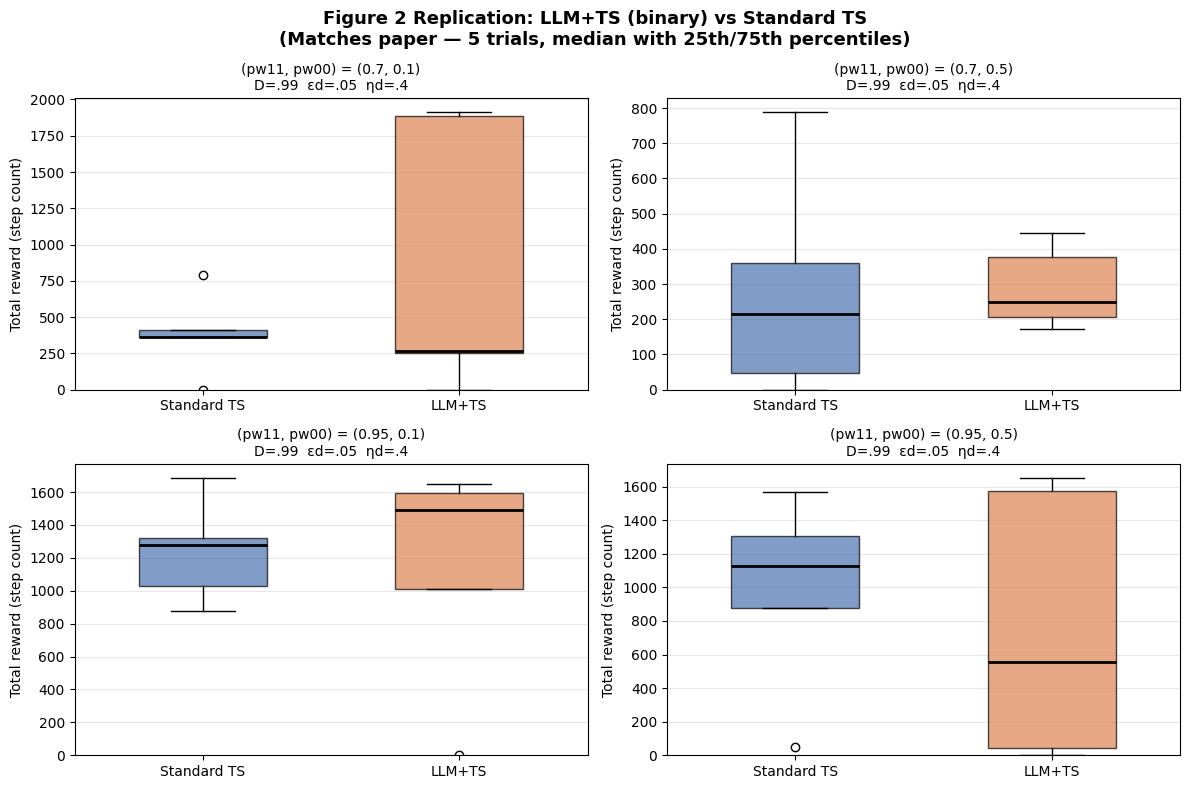

Figure 2 saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Figure 2 Replication: LLM+TS (binary) vs Standard TS\n'
             '(Matches paper — 5 trials, median with 25th/75th percentiles)',
             fontsize=13, fontweight='bold')

scenarios = CFG['SCENARIOS']
compare_methods = ['Standard TS', 'LLM+TS (binary)']
colors = ['#4C72B0', '#DD8452']

for idx, (pw11, pw00) in enumerate(scenarios):
    ax = axes[idx // 2][idx % 2]
    sk = f'pw11={pw11}, pw00={pw00}'
    results = ALL_RESULTS[sk]

    data_to_plot = []
    labels       = []
    for name in compare_methods:
        rewards = [t['total_reward'] for t in results[name]]
        data_to_plot.append(rewards)
        labels.append(name.replace('LLM+TS (binary)', 'LLM+TS'))

    bp = ax.boxplot(data_to_plot, labels=labels,
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(f'(pw11, pw00) = ({pw11}, {pw00})\nD=.99  εd=.05  ηd=.4',
                 fontsize=10)
    ax.set_ylabel('Total reward (step count)')
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_replication.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

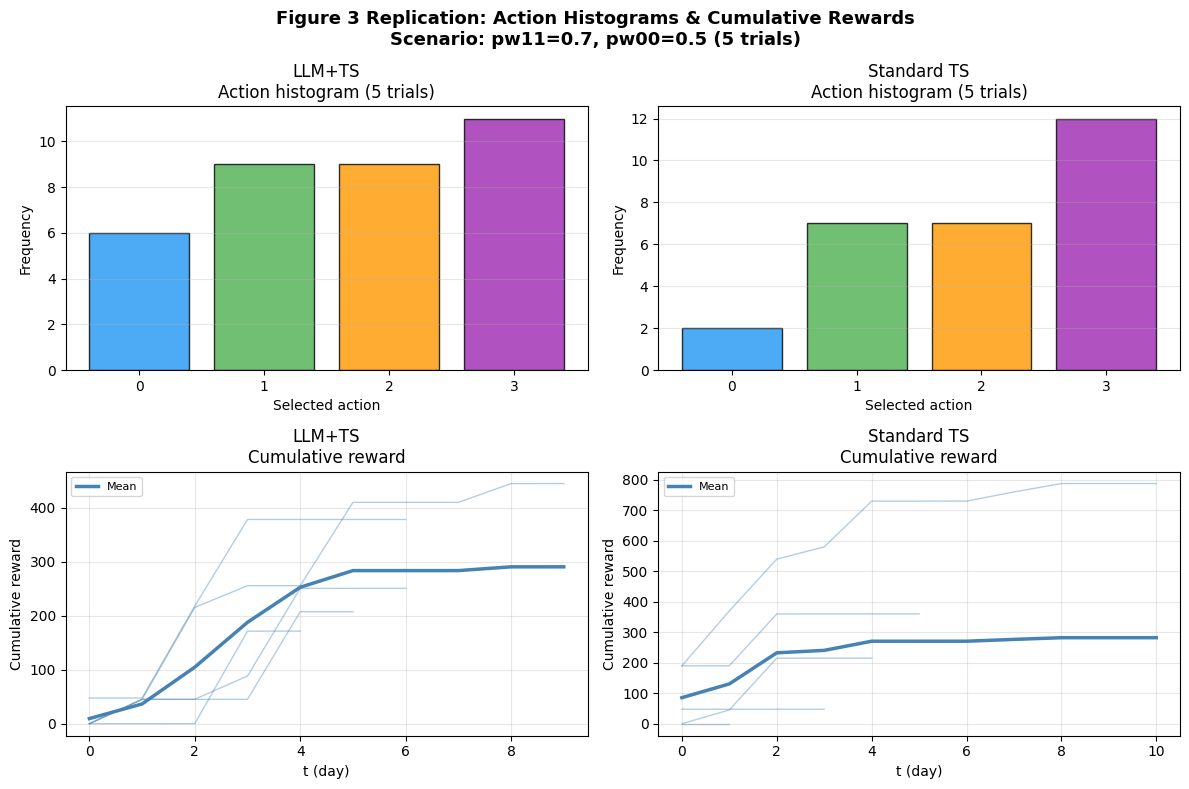

Figure 3 saved.


In [ ]:
scenario_key = f'pw11=0.7, pw00=0.5'
results = ALL_RESULTS[scenario_key]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Figure 3 Replication: Action Histograms & Cumulative Rewards\n'
             f'Scenario: pw11=0.7, pw00=0.5 (5 trials)',
             fontsize=13, fontweight='bold')

for col, name in enumerate(['LLM+TS (binary)', 'Standard TS']):
    trials = results[name]

    all_counts = np.zeros(4)
    for t in trials:
        all_counts += t['action_counts']
    ax = axes[0][col]
    ax.bar(range(4), all_counts, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
           alpha=0.8, edgecolor='black')
    ax.set_xlabel('Selected action')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name.replace("LLM+TS (binary)", "LLM+TS")}\nAction histogram (5 trials)')
    ax.set_xticks(range(4))
    ax.grid(axis='y', alpha=0.3)

    ax2 = axes[1][col]
    for i, t in enumerate(trials):
        cum = t['cumulative']
        ax2.plot(range(len(cum)), cum, alpha=0.4, linewidth=1, color='steelblue')

    max_len = max(len(t['cumulative']) for t in trials)
    padded  = [t['cumulative'] + [t['cumulative'][-1]] * (max_len - len(t['cumulative']))
               for t in trials]
    mean_cum = np.mean(padded, axis=0)
    ax2.plot(range(max_len), mean_cum, color='steelblue', linewidth=2.5, label='Mean')
    ax2.set_xlabel('t (day)')
    ax2.set_ylabel('Cumulative reward')
    ax2.set_title(f'{name.replace("LLM+TS (binary)", "LLM+TS")}\nCumulative reward')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_replication.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

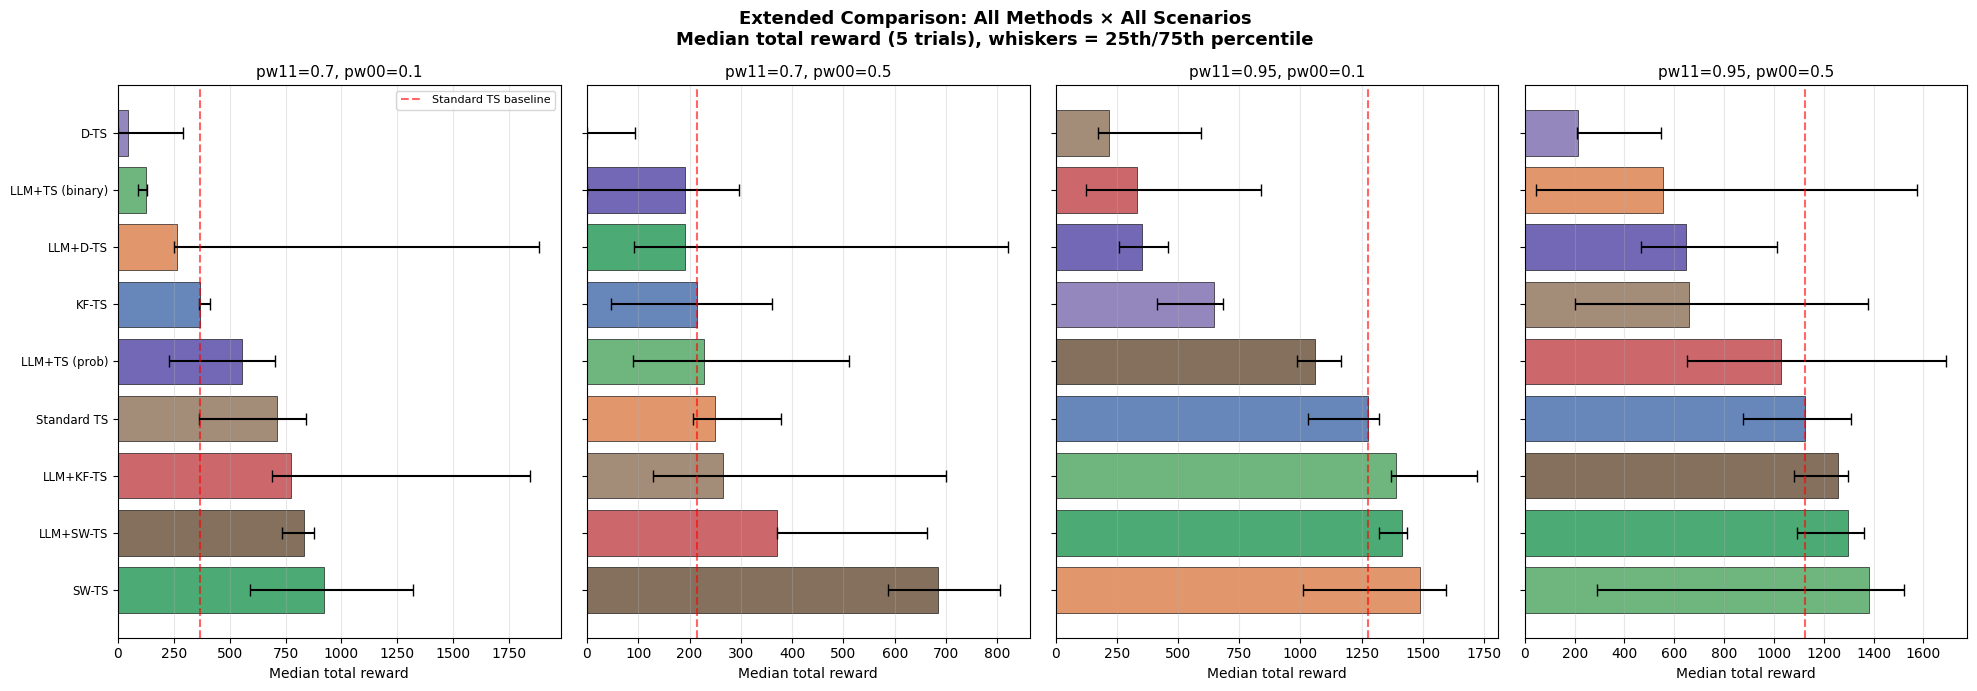

Extended comparison figure saved.


In [ ]:
METHOD_COLORS = {
    'Standard TS':       '#4C72B0',
    'LLM+TS (binary)':   '#DD8452',
    'LLM+TS (prob)':     '#C44E52',
    'SW-TS':             '#55A868',
    'LLM+SW-TS':         '#2D9D5C',
    'D-TS':              '#8172B2',
    'LLM+D-TS':          '#5B4EA8',
    'KF-TS':             '#937860',
    'LLM+KF-TS':         '#6E5740',
}

all_methods = list(METHOD_COLORS.keys())
n_scenarios = len(CFG['SCENARIOS'])

fig, axes = plt.subplots(1, n_scenarios, figsize=(5 * n_scenarios, 7), sharey=True)
fig.suptitle('Extended Comparison: All Methods × All Scenarios\n'
             'Median total reward (5 trials), whiskers = 25th/75th percentile',
             fontsize=13, fontweight='bold')

for s_idx, (pw11, pw00) in enumerate(CFG['SCENARIOS']):
    ax = axes[s_idx]
    sk = f'pw11={pw11}, pw00={pw00}'
    results = ALL_RESULTS[sk]

    medians = []
    q25s    = []
    q75s    = []
    for name in all_methods:
        rewards = [t['total_reward'] for t in results[name]]
        medians.append(np.median(rewards))
        q25s.append(np.percentile(rewards, 25))
        q75s.append(np.percentile(rewards, 75))

    medians = np.array(medians)
    q25s    = np.array(q25s)
    q75s    = np.array(q75s)

    order = np.argsort(medians)[::-1]
    y_pos = range(len(all_methods))

    bars = ax.barh(
        list(y_pos),
        medians[order],
        xerr=[medians[order] - q25s[order], q75s[order] - medians[order]],
        color=[METHOD_COLORS[all_methods[i]] for i in order],
        alpha=0.85,
        capsize=4,
        edgecolor='black',
        linewidth=0.5,
    )
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([all_methods[i] for i in order], fontsize=8.5)
    ax.set_xlabel('Median total reward')
    ax.set_title(f'pw11={pw11}, pw00={pw00}', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(medians[all_methods.index('Standard TS')], color='red',
               linestyle='--', linewidth=1.5, alpha=0.6, label='Standard TS baseline')
    if s_idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('extended_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Extended comparison figure saved.')

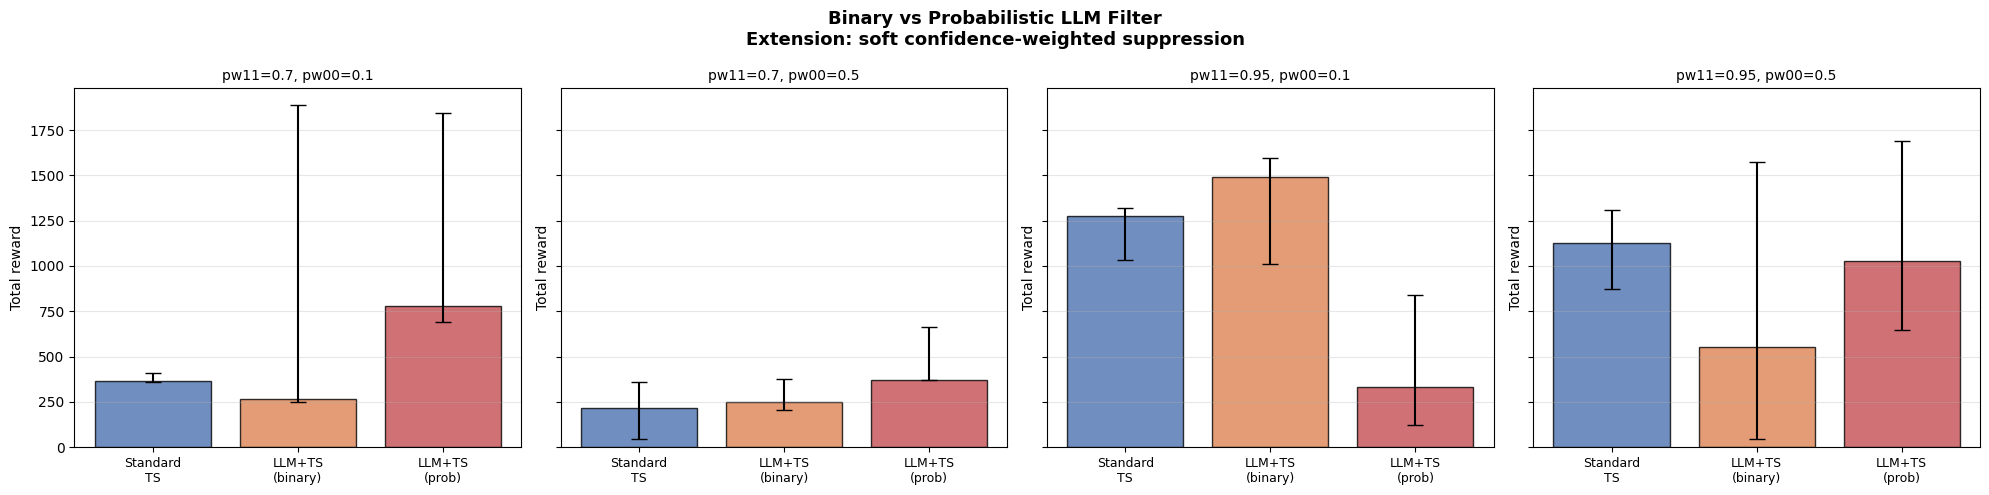

Binary vs probabilistic figure saved.


In [ ]:
fig, axes = plt.subplots(1, n_scenarios, figsize=(5 * n_scenarios, 5), sharey=True)
fig.suptitle('Binary vs Probabilistic LLM Filter\n'
             'Extension: soft confidence-weighted suppression',
             fontsize=13, fontweight='bold')

compare = ['Standard TS', 'LLM+TS (binary)', 'LLM+TS (prob)']
c_colors = ['#4C72B0', '#DD8452', '#C44E52']
width = 0.25

for s_idx, (pw11, pw00) in enumerate(CFG['SCENARIOS']):
    ax = axes[s_idx]
    sk = f'pw11={pw11}, pw00={pw00}'
    results = ALL_RESULTS[sk]

    x = np.arange(len(compare))
    for i, name in enumerate(compare):
        rewards  = [t['total_reward'] for t in results[name]]
        med = np.median(rewards)
        q25 = np.percentile(rewards, 25)
        q75 = np.percentile(rewards, 75)
        ax.bar(i, med, yerr=[[med - q25], [q75 - med]],
               color=c_colors[i], alpha=0.8, capsize=6, edgecolor='black',
               label=name)

    ax.set_title(f'pw11={pw11}, pw00={pw00}', fontsize=10)
    ax.set_xticks(range(len(compare)))
    ax.set_xticklabels(['Standard\nTS', 'LLM+TS\n(binary)', 'LLM+TS\n(prob)'], fontsize=9)
    ax.set_ylabel('Total reward')
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('binary_vs_probabilistic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Binary vs probabilistic figure saved.')

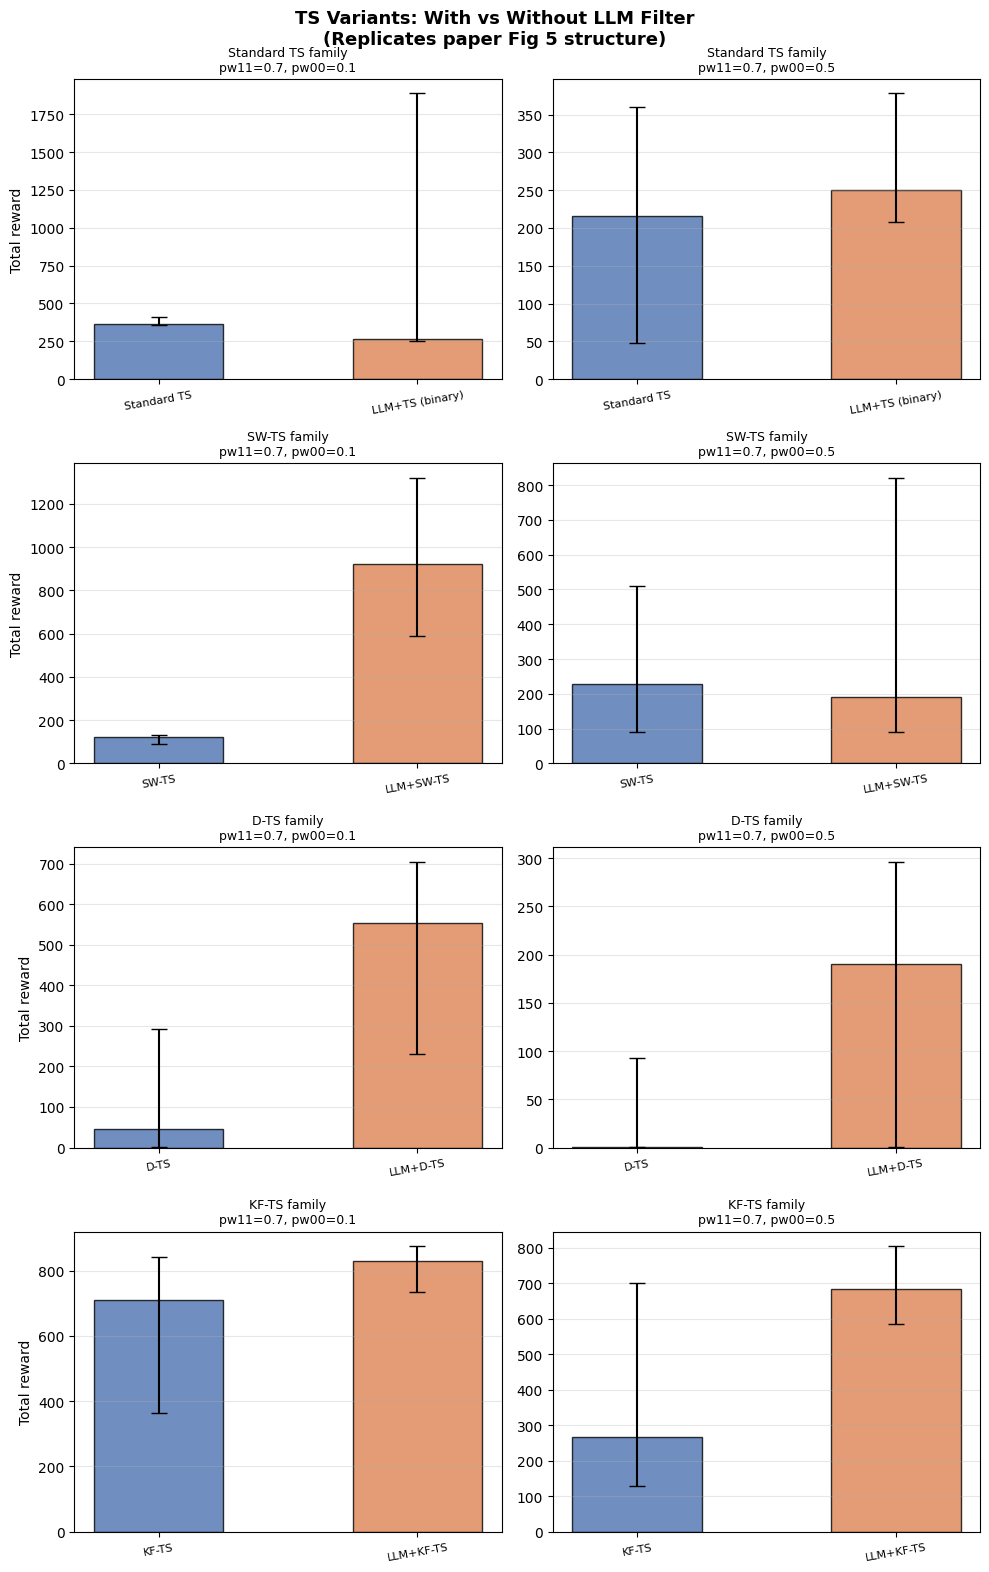

TS variants LLM comparison figure saved.


In [ ]:
ts_pairs = [
    ('Standard TS',  'LLM+TS (binary)'),
    ('SW-TS',        'LLM+SW-TS'),
    ('D-TS',         'LLM+D-TS'),
    ('KF-TS',        'LLM+KF-TS'),
]

selected_scenarios = CFG['SCENARIOS'][:2]

fig, axes = plt.subplots(len(ts_pairs), len(selected_scenarios),
                          figsize=(5 * len(selected_scenarios), 4 * len(ts_pairs)),
                          squeeze=False)
fig.suptitle('TS Variants: With vs Without LLM Filter\n'
             '(Replicates paper Fig 5 structure)',
             fontsize=13, fontweight='bold')

for row, (no_llm, with_llm) in enumerate(ts_pairs):
    for col, (pw11, pw00) in enumerate(selected_scenarios):
        ax  = axes[row][col]
        sk  = f'pw11={pw11}, pw00={pw00}'
        res = ALL_RESULTS[sk]

        for i, (name, color) in enumerate([(no_llm, '#4C72B0'), (with_llm, '#DD8452')]):
            rewards = [t['total_reward'] for t in res[name]]
            med = np.median(rewards)
            q25 = np.percentile(rewards, 25)
            q75 = np.percentile(rewards, 75)
            ax.bar(i, med, yerr=[[med - q25], [q75 - med]],
                   color=color, alpha=0.8, capsize=6,
                   edgecolor='black', width=0.5)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([no_llm, f'{with_llm}'], fontsize=8, rotation=10)
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', alpha=0.3)
        if col == 0:
            ax.set_ylabel('Total reward')
        ax.set_title(f'{no_llm} family\npw11={pw11}, pw00={pw00}', fontsize=9)

plt.tight_layout()
plt.savefig('ts_variants_llm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('TS variants LLM comparison figure saved.')

## 10. Summary Table — Best Method per Scenario

In [ ]:
print('=' * 80)
print('RESULTS SUMMARY TABLE')
print('Median total reward (IQR) across 5 trials per scenario')
print('=' * 80)

header = f"{'Method':<22}" + ''.join(f"{f'pw11={p[0]},pw00={p[1]}':>20}" for p in CFG['SCENARIOS'])
print(header)
print('-' * (22 + 20 * len(CFG['SCENARIOS'])))

for name in all_methods:
    row = f'{name:<22}'
    best_in_row = []
    for pw11, pw00 in CFG['SCENARIOS']:
        sk      = f'pw11={pw11}, pw00={pw00}'
        rewards = [t['total_reward'] for t in ALL_RESULTS[sk][name]]
        med     = np.median(rewards)
        q25     = np.percentile(rewards, 25)
        q75     = np.percentile(rewards, 75)
        best_in_row.append(med)
        row += f'{med:>12.1f} ({q25:.0f}–{q75:.0f})'
    print(row)

print()
print('BEST METHOD PER SCENARIO:')
print('-' * 60)
for pw11, pw00 in CFG['SCENARIOS']:
    sk = f'pw11={pw11}, pw00={pw00}'
    best_name = None
    best_med  = -np.inf
    for name in all_methods:
        rewards = [t['total_reward'] for t in ALL_RESULTS[sk][name]]
        med = np.median(rewards)
        if med > best_med:
            best_med  = med
            best_name = name
    # Improvement over standard TS
    std_rewards = [t['total_reward'] for t in ALL_RESULTS[sk]['Standard TS']]
    std_med     = np.median(std_rewards)
    improvement = ((best_med - std_med) / max(std_med, 1e-6)) * 100
    print(f'  pw11={pw11}, pw00={pw00}: {best_name:<22} '
          f'(median={best_med:.1f}, +{improvement:.1f}% vs Standard TS)')

RESULTS SUMMARY TABLE
Median total reward (IQR) across 5 trials per scenario
Method                   pw11=0.7,pw00=0.1   pw11=0.7,pw00=0.5  pw11=0.95,pw00=0.1  pw11=0.95,pw00=0.5
------------------------------------------------------------------------------------------------------
Standard TS                  365.5 (360–411)       215.3 (48–360)      1276.4 (1031–1320)      1126.0 (876–1309)
LLM+TS (binary)              264.5 (251–1887)       250.5 (207–378)      1488.7 (1010–1596)       555.8 (45–1576)
LLM+TS (prob)                776.6 (691–1846)       370.6 (370–664)       330.5 (123–840)      1026.1 (649–1692)
SW-TS                        124.0 (90–131)       227.8 (89–510)      1389.8 (1371–1723)      1381.6 (290–1521)
LLM+SW-TS                    923.6 (591–1322)       190.3 (91–822)      1414.4 (1321–1434)      1295.4 (1091–1362)
D-TS                          45.6 (0–292)         0.2 (0–93)       647.4 (412–682)       215.4 (209–546)
LLM+D-TS                     554.6 (231–705)

ANALYSIS: LLM Filter Intervention Rate & Episode Lengths


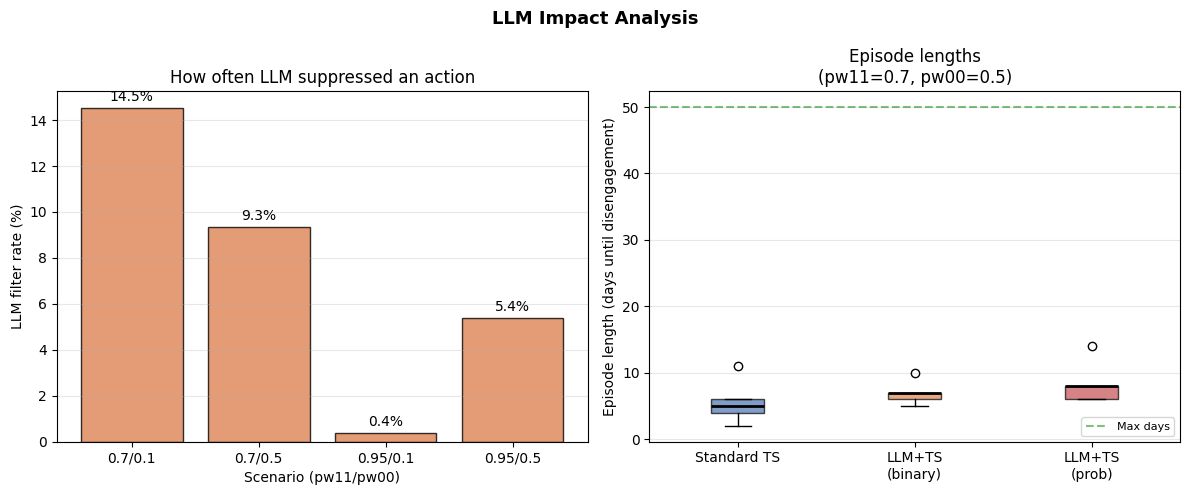


Episode length analysis (pw11=0.7, pw00=0.5):
  Standard TS           : mean=5.6 days, median=5.0
  LLM+TS (binary)       : mean=7.0 days, median=7.0
  LLM+TS (prob)         : mean=8.4 days, median=8.0


In [ ]:
print('ANALYSIS: LLM Filter Intervention Rate & Episode Lengths')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LLM Impact Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
filter_rates = {}
for pw11, pw00 in CFG['SCENARIOS']:
    sk = f'pw11={pw11}, pw00={pw00}'
    llm_binary_trials = ALL_RESULTS[sk]['LLM+TS (binary)']
    rates = []
    for t in llm_binary_trials:
        total_steps = t['episode_length']
        n_filtered  = t['llm_filter_count']
        rates.append(n_filtered / max(total_steps, 1))
    filter_rates[f'{pw11}/{pw00}'] = rates

labels  = list(filter_rates.keys())
values  = [np.mean(v) * 100 for v in filter_rates.values()]
ax.bar(labels, values, color='#DD8452', alpha=0.8, edgecolor='black')
ax.set_xlabel('Scenario (pw11/pw00)')
ax.set_ylabel('LLM filter rate (%)')
ax.set_title('How often LLM suppressed an action')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

ax2 = axes[1]
scenario_key = f'pw11=0.7, pw00=0.5'
compare_for_length = {
    'Standard TS':     ALL_RESULTS[scenario_key]['Standard TS'],
    'LLM+TS (binary)': ALL_RESULTS[scenario_key]['LLM+TS (binary)'],
    'LLM+TS (prob)':   ALL_RESULTS[scenario_key]['LLM+TS (prob)'],
}
ep_lengths = {name: [t['episode_length'] for t in trials]
              for name, trials in compare_for_length.items()}

bp = ax2.boxplot(list(ep_lengths.values()),
                 labels=[n.replace(' (binary)', '\n(binary)').replace(' (prob)', '\n(prob)')
                         for n in ep_lengths.keys()],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#C44E52']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('Episode length (days until disengagement)')
ax2.set_title(f'Episode lengths\n(pw11=0.7, pw00=0.5)')
ax2.axhline(CFG['MAX_DAYS'], color='green', linestyle='--', alpha=0.5, label='Max days')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('llm_impact_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEpisode length analysis (pw11=0.7, pw00=0.5):')
for name, lengths in ep_lengths.items():
    print(f'  {name:<22}: mean={np.mean(lengths):.1f} days, '
          f'median={np.median(lengths):.1f}')